# Phase 3: Signal taxonomy: circuits, aggregates, sign, units

1. Census every `circuit_type`, by `is_pv` : how many circuits, at how many sites.
2. Scan circuit_type names for battery/EV candidates (a hypothesis only)
3. Flag which circuit_types LOOK like whole-site aggregates by name (a hypothesis only) and separately measure fleet-wide sub-metering completeness.
4. **PROVE, arithmetically, interval by interval, whether each suspected aggregate actually equals the sum of its siblings** -- 
   do not infer this from the name "net" alone, and never conclude from a single site either.
   (see `ami_config.py`'s CIRCUIT -> SIGNAL MAPPING section): a site carrying both `ac_load_net` and its own sub-loads would have its `gross_load` silently doubled if we summed both.
5. Verify `circuit_polarity` actually makes each circuit_type's readings one-signed (as the existing pipeline assumes for PV), 
   and separately confirm or rule out bidirectional (battery/EV, or an unexpectedly bidirectional "load") behaviour.
6. Verify which of `power` / `energy_reactive` is instantaneous vs already an energy, against the data itself, not the docstring it was read off.
7. Demonstrate the resample rule that follows on a real sample.
8. Example daily curves for a small, deliberately-chosen, SIMPLE site (few circuits)

**Convention pending confirmation, not decided here:** the target AMI
interval (`ami_config.TARGET_INTERVAL_MINUTES`, currently a 30-minute
placeholder). This notebook verifies the *source* column units and the
*resample rule*, which hold regardless of the target interval chosen -- the
interval itself is a policy choice for you to confirm at the end, the same
way the source dataset was in Phase 2.


In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

_current = Path.cwd().resolve()
REPO_ROOT = next(
    (p for p in (_current, *_current.parents) if (p / "bms_sa_review").is_dir()),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError(f"Could not locate the CICCADA repository root from {_current}")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from bms_sa_review.ami_data_analysis.config import ami_config as Config
from bms_sa_review.ami_data_analysis.lib import ami_athena as Athena
from bms_sa_review.ami_data_analysis.lib import ami_taxonomy as Taxonomy
from bms_sa_review.ami_data_analysis.lib import ami_signal as Signal
from bms_sa_review.ami_data_analysis.lib import ami_resample as Resample
from bms_sa_review.ami_data_analysis.lib import ami_plots as Plots

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)

Athena.reset_scan_log()
Athena.require_credentials()
print("Credentials OK. Starting signal taxonomy.")


Credentials OK. Starting signal taxonomy.


## 1. Circuit-type census

One row per (`circuit_type`, `is_pv`), grouped in SQL on `meta_up23c` 


In [2]:
raw_circuit_type_counts = Athena.aq(
    """
    SELECT circuit_type, is_pv, count(*) AS n_circuits, count(DISTINCT site_id) AS n_sites
    FROM meta_up23c
    GROUP BY circuit_type, is_pv
    """,
    database=Config.SAI, label="circuit_type census",
)

census = Taxonomy.summarise_circuit_types(raw_circuit_type_counts)
census = Taxonomy.flag_suspected_aggregates(census)
display(census)

suspects = census[census.suspected_aggregate]
print(f"\n{len(suspects)} circuit_type(s) flagged as SUSPECTED aggregates by name "
      f"(not proven yet -- see section 4): {suspects.circuit_type.tolist()}")


,circuit_type,is_pv,n_circuits,n_sites,share_within_is_pv,suspected_aggregate
0,ac_load_net,False,26120,15048,0.780587,True
1,load_air_conditioner,False,1767,1462,0.052806,False
2,load_other,False,1260,865,0.037655,False
3,load_powerpoint,False,1010,702,0.030183,False
4,load_hot_water,False,727,688,0.021726,False
5,load_stove,False,534,493,0.015958,False
6,load_lighting,False,353,334,0.010549,False
7,load_pool,False,291,275,0.008696,False
8,battery_storage,False,184,164,0.005499,False
9,load_subboard,False,154,82,0.004602,False



4 circuit_type(s) flagged as SUSPECTED aggregates by name (not proven yet -- see section 4): ['ac_load_net', 'pv_site_net', 'pv_site', 'pv_inverter_net']


## 2. Battery / EV name scan (hypothesis)

Pure name-pattern check across every circuit_type seen in the census no query. 

Done now, before completeness and aggregation below, because a storage circuit must be set aside from both: it should not count as a
"load" for coverage purposes in the same way an ordinary sub-load does


In [3]:
storage_flags = Signal.classify_storage_circuits(census.circuit_type.unique())
storage_suspects = [t for t, flagged in storage_flags.items() if flagged]

if storage_suspects:
    print(f"circuit_type(s) whose NAME suggests battery/EV: {storage_suspects}")
    print("Section 5 checks whether their readings are actually bidirectional.")
else:
    print("No circuit_type name matched battery/EV keywords "
          f"({sorted(Signal.STORAGE_KEYWORDS)}).")
    print("Either this fleet has no separately-metered storage, or it uses a "
          "naming convention this keyword list hasn't seen -- worth a manual "
          "skim of the circuit_type list above if you know of BESS/EV sites here.")


circuit_type(s) whose NAME suggests battery/EV: ['battery_storage', 'load_ev_charger']
Section 5 checks whether their readings are actually bidirectional.


## 3. Fleet-wide sub-metering completeness

- Pull the full `meta_up23c` circuit -> site -> type mapping once 
- reuse it for the rest of this notebook

- Coverage is measured over EVERY circuit_type on each side, including suspected aggregates and storage 
- a `pv_site_net` circuit still counts as PV present at a site for this purpose, even though it may be excluded from the actual signal *sum* once section 4 has a verdict. 
- Conflating "counts as
present" with "counts toward the sum" would silently understate coverage on
any fleet whose dominant PV circuit_type name happens to look aggregate-ish
(as it does here: `pv_site_net` is 99.6% of PV-side circuits).


In [4]:
meta_local = Athena.aq(
    """
    SELECT circuit_id, site_id, circuit_type, is_pv, circuit_polarity, ac_capacity_kw,
           device_id, m_id, device_type, voltage_class, min_time, max_time, s_99
    FROM meta_up23c
    """,
    database=Config.SAI, label="meta_up23c full projection",
)

print(f"meta_local: {len(meta_local):,} rows, {meta_local.circuit_id.nunique():,} distinct circuits")

cohort = Taxonomy.cohort_completeness(meta_local)

pv_types = census[census.is_pv.astype(bool)].circuit_type.tolist()
load_types = census[~census.is_pv.astype(bool)].circuit_type.tolist()
print(f"\nall PV-side types:   {pv_types}")
print(f"all load-side types: {load_types}")

coverage = Taxonomy.signal_coverage_summary(cohort, pv_types=pv_types, load_types=load_types)
display(pd.DataFrame([coverage]))

pv_cols = [t for t in pv_types if t in cohort.columns]
load_cols = [t for t in load_types if t in cohort.columns]
pv_present = cohort[pv_cols].sum(axis=1) > 0 if pv_cols else pd.Series(False, index=cohort.index)
load_present = cohort[load_cols].sum(axis=1) > 0 if load_cols else pd.Series(False, index=cohort.index)
cohort_with_both = cohort[pv_present & load_present].reset_index(drop=True)
print()
print(f"{len(cohort_with_both):,} of {len(cohort):,} sites have at least one PV-side AND "
      "one load-side circuit_type present. Site-selection below (sections 4, 8, 9) is "
      "restricted to this pool -- a site missing one whole side cannot serve as ground truth "
      "for solar disaggregation no matter how clean its circuits are, so there is no reason "
      "to spend a query, or an illustrative plot, on one.")


meta_local: 60,570 rows, 60,570 distinct circuits

all PV-side types:   ['pv_site_net', 'pv_site', 'pv_inverter_net', 'pv_inverter']
all load-side types: ['ac_load_net', 'load_air_conditioner', 'load_other', 'load_powerpoint', 'load_hot_water', 'load_stove', 'load_lighting', 'load_pool', 'battery_storage', 'load_subboard', 'load_shed', 'ac_load', 'load_kitchen', 'load_hot_water_solar', 'load_spa', 'load_tenant', 'load_laundry', 'load_ev_charger', 'load_common_area', 'load_garage', 'load_studio', 'load_refrigerator', 'load_office', 'load_machine', 'load_air_compressor', 'load_washer', 'load_generator', 'load_hot_water_heat_pump', 'load_security']


,n_sites,n_with_both,share_with_both,n_pv_only,n_load_only,n_neither
0,16148,15167,0.939249,981,0,0



15,167 of 16,148 sites have at least one PV-side AND one load-side circuit_type present. Site-selection below (sections 4, 8, 9) is restricted to this pool -- a site missing one whole side cannot serve as ground truth for solar disaggregation no matter how clean its circuits are, so there is no reason to spend a query, or an illustrative plot, on one.


### 3b. How many `ac_load_net`-type circuit_ids per PV site?

Does a PV site with more than one `ac_load_net` circuit_id mean separately-metered PHASES (a 3-phase connection read as three circuit_ids, L1/L2/L3), 
rather than the duplicate/dead-circuit causes section 8 checks for at the individual-site level? 

This cell only COUNTS it cannot distinguish phases from duplicates/dead circuits by itself 
(that needs section 8's per-site correlation/activity checks), 
but the shape of the distribution below is a first clue: a count that clusters at exactly 3 is consistent with phases, anything else points elsewhere.

"PV site" here reuses the same `pv_present` mask that built `cohort_with_both` above at least one `is_pv=True` circuit present at the site, from the fleet-wide `meta_up23c` pivot already pulled in section 3.

Deliberately NOT restricted to `cohort_with_both`: 
a PV-only site (no load-side circuit at all) still answers "does this PV site have multiple `ac_load_net`", so narrowing to the both-sides cohort first would silently drop some of the population this question is about.


In [5]:
pv_cohort = cohort[pv_present].reset_index(drop=True)
print(f"{len(pv_cohort):,} of {len(cohort):,} sites have at least one is_pv=True "
      "circuit (the `pv_present` mask used for `cohort_with_both` above -- PV-only "
      "sites are included here, not just sites with both sides present).")

load_suspects = suspects[suspects.is_pv.astype(bool) == False].circuit_type.tolist()
load_candidate_type = load_suspects[0] if load_suspects else None

if load_candidate_type and load_candidate_type in pv_cohort.columns:
    ac_load_counts = pv_cohort[load_candidate_type]
    n_zero = int((ac_load_counts == 0).sum())
    n_one = int((ac_load_counts == 1).sum())
    n_multi = int((ac_load_counts > 1).sum())

    print(f"\nOf those {len(pv_cohort):,} PV site(s), for `{load_candidate_type}`:")
    print(f"  {n_zero:,} have NO `{load_candidate_type}` circuit at all")
    print(f"  {n_one:,} have exactly 1 `{load_candidate_type}` circuit_id")
    print(f"  {n_multi:,} have MORE THAN 1 `{load_candidate_type}` circuit_id")

    if n_multi:
        distribution = ac_load_counts[ac_load_counts > 1].value_counts().sort_index()
        distribution.index.name = f"n_{load_candidate_type}_circuits"
        display(distribution.rename("n_sites").to_frame())
        print(f"\nMost `{load_candidate_type}` circuit_ids at one PV site: "
              f"{int(ac_load_counts.max())}")
        print("A count clustering at exactly 3 would be consistent with "
              "separately-metered phases; other patterns point more toward "
              "the duplicate/dead-circuit causes section 8 checks for.")
else:
    if load_candidate_type:
        print(f"`{load_candidate_type}` not present in the coverage pivot -- skipping.")
    else:
        print("No suspected load-side aggregate circuit_type found -- skipping.")


16,148 of 16,148 sites have at least one is_pv=True circuit (the `pv_present` mask used for `cohort_with_both` above -- PV-only sites are included here, not just sites with both sides present).

Of those 16,148 PV site(s), for `ac_load_net`:
  1,100 have NO `ac_load_net` circuit at all
  9,294 have exactly 1 `ac_load_net` circuit_id
  5,754 have MORE THAN 1 `ac_load_net` circuit_id


,n_sites
n_ac_load_net_circuits,
2,623
3,5059
4,13
5,3
6,56



Most `ac_load_net` circuit_ids at one PV site: 6
A count clustering at exactly 3 would be consistent with separately-metered phases; other patterns point more toward the duplicate/dead-circuit causes section 8 checks for.


### 3c. What are `device_id`/`m_id`, and do multi-circuit sites share one device?

`device_id` groups circuit_ids that belong to one physical metering device
(per the historical data-dump documentation) -- circuit_ids sharing a
`device_id` at one site are separately-metered channels of THAT device
(e.g. a 3-phase meter's L1/L2/L3), which is stronger, registration-level
evidence for "these are phases" than any behavioural correlation check.
`m_id`'s meaning wasn't known going in -- `grouping_keys_agree` checks
whether it's the same grouping as `device_id` under a different name, or
something else, directly rather than by assumption.

This also answers section 3b's open question with real evidence instead of
just a count: for PV sites with more than one `ac_load_net` circuit_id, do
those circuit_ids share ONE `device_id` (phase/channel-like) or span
MULTIPLE `device_id`s (duplicate/independent-registration-like -- the
individual-site checks in section 8 are what resolve those)?


In [6]:
m_id_check = Taxonomy.grouping_keys_agree(meta_local, key_a="m_id", key_b="device_id")
print("m_id <-> device_id:", m_id_check["reason"])

if "voltage_class" in meta_local.columns:
    voltage_classes = sorted(meta_local.voltage_class.dropna().unique().tolist())
    print(f"\nvoltage_class distinct values: {voltage_classes}")

if load_candidate_type:
    device_grouping = Taxonomy.circuits_grouped_by_device(
        meta_local, candidate_type=load_candidate_type
    )
    if len(device_grouping):
        n_single = int(device_grouping.single_device.sum())
        n_multi_device = len(device_grouping) - n_single
        print(f"\nOf the {len(device_grouping):,} PV site(s) with more than one "
              f"`{load_candidate_type}` circuit_id (section 3b):")
        print(f"  {n_single:,} have all of them under ONE device_id -- phase/channel-like")
        print(f"  {n_multi_device:,} span MULTIPLE device_ids -- duplicate/independent-like, "
              "candidates for section 8's find_duplicate_circuits/find_inactive_circuits")
        display(device_grouping.head(10))
    else:
        print(f"\nNo multi-circuit `{load_candidate_type}` site found, or `device_id` not "
              "available in meta_local -- skipping the device-grouping check.")
else:
    print("No suspected load-side aggregate circuit_type found -- skipping.")


m_id <-> device_id: m_id <-> device_id: 33 m_id value(s) span more than one device_id, 0 device_id value(s) span more than one m_id -- these are different groupings, not the same key twice

voltage_class distinct values: ['absorb', 'neutral', 'neutral-absorb', 'supply', 'supply-neutral', 'supply-neutral-absorb']

Of the 5,754 PV site(s) with more than one `ac_load_net` circuit_id (section 3b):
  5,407 have all of them under ONE device_id -- phase/channel-like
  347 span MULTIPLE device_ids -- duplicate/independent-like, candidates for section 8's find_duplicate_circuits/find_inactive_circuits


,site_id,n_circuits,n_distinct_devices,single_device
0,1002469,3,1,True
1,1024617,3,1,True
2,1273973,3,1,True
3,1532067,3,1,True
4,1729126,3,1,True
5,1751786,3,1,True
6,2063970,3,1,True
7,2071379,3,1,True
8,2934556,3,1,True
9,3897159,3,1,True


### 3d. Restricting to "clean" phase counts (1 or 3 `ac_load_net`)

Section 3b's count alone cannot tell a real 3-phase site from a
duplicate/dead-circuit one -- section 3c's `device_id` check is the
stronger evidence for that. But for picking a **clean starting cohort** to
build ground truth from (rather than resolving every messy site up front),
a simple filter on the count itself is a reasonable first cut: 1 circuit is
unambiguous (single-phase), and 3 is the single dominant multi-circuit
count in the fleet (section 3b's real-fleet distribution was
`{2: 623, 3: 5059, 4: 13, 5: 3, 6: 56}` -- 3 alone is 88% of all
multi-circuit sites). Counts of 2, 4, 5, or 6 are the ones most likely to
include a duplicate or dead circuit_id (an odd count in particular cannot
be a complete 3-phase reading), so they are cross-checked against section
3c's device_id evidence below before being written off entirely.

This does not change sections 4 or 6 above -- those already ran against
the full cohort. It defines `CLEAN_SITE_IDS`/`OTHER_COUNT_SITE_IDS` for
later use (e.g. as a restriction in Phase 4, or when picking illustrative
sites in section 8).

In [7]:
CLEAN_AC_LOAD_NET_COUNTS = {1, 3}  # single-phase, or the dominant 3-phase count

if load_candidate_type and load_candidate_type in pv_cohort.columns:
    counts_by_site = pv_cohort[["site_id", load_candidate_type]].rename(
        columns={load_candidate_type: "n_circuits"}
    )
    counts_by_site = counts_by_site[counts_by_site.n_circuits > 0]

    is_clean = counts_by_site.n_circuits.isin(CLEAN_AC_LOAD_NET_COUNTS)
    CLEAN_SITE_IDS = counts_by_site.loc[is_clean, "site_id"].tolist()
    OTHER_COUNT_SITE_IDS = counts_by_site.loc[~is_clean, "site_id"].tolist()

    print(f"{len(CLEAN_SITE_IDS):,} of {len(counts_by_site):,} site(s) with at least one "
          f"`{load_candidate_type}` circuit have exactly 1 or 3 -- the counts consistent "
          "with a genuine single-phase or fully-metered 3-phase connection.")
    print(f"{len(OTHER_COUNT_SITE_IDS):,} have some other count (2, 4, 5, 6, ...) -- the "
          "ones most likely to include a duplicate/dead circuit_id rather than a real "
          "extra phase.")

    if OTHER_COUNT_SITE_IDS and len(device_grouping):
        # Not every "other count" site is necessarily bad: cross-check
        # against section 3c's device_id evidence before recommending
        # outright exclusion -- e.g. a 2-circuit split-phase connection
        # sharing one device_id is still phase/channel-like despite the
        # unusual count, not a duplicate.
        other_with_device_evidence = device_grouping[
            device_grouping.site_id.isin(OTHER_COUNT_SITE_IDS)
        ]
        n_other_single_device = int(other_with_device_evidence.single_device.sum())
        n_other_multi_device = len(other_with_device_evidence) - n_other_single_device
        print(f"\nOf those {len(OTHER_COUNT_SITE_IDS):,} 'other count' site(s), section "
              f"3c's device_id check covers {len(other_with_device_evidence):,}: "
              f"{n_other_single_device:,} still share ONE device_id (phase/channel-like "
              f"despite the unusual count) and {n_other_multi_device:,} span multiple "
              "device_ids (the stronger duplicate/dead-circuit signal).")

    print(f"\n`CLEAN_SITE_IDS` ({len(CLEAN_SITE_IDS):,}) and `OTHER_COUNT_SITE_IDS` "
          f"({len(OTHER_COUNT_SITE_IDS):,}) are now available for the rest of this "
          "notebook and for Phase 4. Section 4 below reads `CLEAN_SITE_IDS` directly "
          "(via `RESTRICT_TO_CLEAN_SITES`) for the load-side (`ac_load_net`) site "
          "selection -- sections 5-8 inherit whatever section 4 tested, since they "
          "all build from its `combined_sample`/`simplest`. Note this restriction is "
          "unrelated to section 6's energy-matching mismatch: cross-checked against "
          "real data, that traces to specific circuit_ids' `energy` logging (see the "
          "diagnostic after section 6b), not circuit count -- restricting by count "
          "would not, by itself, have fixed it.")
else:
    CLEAN_SITE_IDS, OTHER_COUNT_SITE_IDS = [], []
    print("No suspected load-side aggregate circuit_type found -- skipping.")

14,353 of 15,048 site(s) with at least one `ac_load_net` circuit have exactly 1 or 3 -- the counts consistent with a genuine single-phase or fully-metered 3-phase connection.
695 have some other count (2, 4, 5, 6, ...) -- the ones most likely to include a duplicate/dead circuit_id rather than a real extra phase.

Of those 695 'other count' site(s), section 3c's device_id check covers 695: 362 still share ONE device_id (phase/channel-like despite the unusual count) and 333 span multiple device_ids (the stronger duplicate/dead-circuit signal).

`CLEAN_SITE_IDS` (14,353) and `OTHER_COUNT_SITE_IDS` (695) are now available for the rest of this notebook and for Phase 4. Section 4 below reads `CLEAN_SITE_IDS` directly (via `RESTRICT_TO_CLEAN_SITES`) for the load-side (`ac_load_net`) site selection -- sections 5-8 inherit whatever section 4 tested, since they all build from its `combined_sample`/`simplest`. Note this restriction is unrelated to section 6's energy-matching mismatch: cross-check

## 4. Proving aggregation status arithmetically

- For each `is_pv` side, this takes the circuit_type the name-scan flagged as the dominant suspected aggregate, 
- tests it at a SPREAD of real sites rather than just one: the `N_MOST_INSTRUMENTED` sites with the most sibling circuits present

- The sibling/component list EXCLUDES storage-suspected types (section 2) 
- A battery is not a candidate's "sibling" in this sum, proven or not, because it does not belong in `gross_load`. 
- Each check's `component_types` records the types ACTUALLY present at that specific site, not the full fleet-wide candidate list 
- a site is not implied to have every type shown in the fleet-wide census.


In [8]:
RUN_AGGREGATION_CHECKS = True  # set False to skip

AGGREGATION_DAY_START = "2025-06-01 00:00:00"
AGGREGATION_DAY_END = "2025-06-02 00:00:00"
AGGREGATION_YEAR, AGGREGATION_MONTH = 2025, 6
N_MOST_INSTRUMENTED = 0
N_SIMPLEST = 10

# Section 3d's "clean" (1 or 3 circuit) load-side site filter -- set
# False to go back to testing against the full `cohort_with_both`.
# Only applies to the LOAD side (`candidate_type == load_candidate_type`):
# `CLEAN_SITE_IDS` is defined purely from `ac_load_net` counts, so it has
# no bearing on the PV-side candidate (`pv_site_net`/`pv_site`).
RESTRICT_TO_CLEAN_SITES = True

aggregation_checks = []
aggregation_samples = {}  # site_id -> real ts rows pulled here, reused in sections 5-7

if RUN_AGGREGATION_CHECKS:
    for is_pv_value in (False, True):
        side_suspects = suspects[suspects.is_pv.astype(bool) == is_pv_value].circuit_type.tolist()
        side_components = census[
            (census.is_pv.astype(bool) == is_pv_value) & (~census.suspected_aggregate)
        ].circuit_type.tolist()
        side_components = [t for t in side_components if not storage_flags.get(t, False)]

        if not side_suspects:
            print(f"is_pv={is_pv_value}: no suspected-aggregate circuit_type -- nothing to test.")
            continue
        if not side_components:
            print(f"is_pv={is_pv_value}: no non-aggregate, non-storage sibling types anywhere "
                  "in the fleet -- skipping (this itself is informative: it means this side has "
                  "essentially no sub-metering to test against).")
            continue

        candidate_type = side_suspects[0]

        site_pool = cohort_with_both
        if RESTRICT_TO_CLEAN_SITES and candidate_type == load_candidate_type and CLEAN_SITE_IDS:
            site_pool = cohort_with_both[cohort_with_both.site_id.isin(CLEAN_SITE_IDS)]
            print(f"  (RESTRICT_TO_CLEAN_SITES=True: `{candidate_type}` site selection "
                  f"limited to the {len(site_pool):,} 'clean' site(s) from section 3d, "
                  f"out of {len(cohort_with_both):,} in the full cohort_with_both)")

        ranked_sites = Taxonomy.pick_aggregation_test_site(
            site_pool, candidate_type=candidate_type, component_types=side_components,
        )
        if not ranked_sites:
            print(f"is_pv={is_pv_value}: no site has both `{candidate_type}` and a sibling -- skipping.")
            continue

        test_site_ids = list(dict.fromkeys(
            ranked_sites[:N_MOST_INSTRUMENTED] + ranked_sites[-N_SIMPLEST:]
        ))

        # Day-coverage pre-check: one cheap DISTINCT-circuit_id query for the
        # WHOLE batch, before the expensive per-site pulls below. A real run
        # at N=200 came back 83/200 inconclusive -- indistinguishable in the
        # results table from a genuine partial-overlap case, but most of
        # that turned out to be sites whose circuits are listed in
        # meta_up23c yet never reported a single row this day (real fleet
        # churn). This tells the two apart and skips the doomed sites
        # up front, rather than paying for a per-site query that can only
        # ever come back inconclusive.
        presence_ids = sorted(set(
            meta_local[
                (meta_local.site_id.isin(test_site_ids))
                & (meta_local.circuit_type.isin([candidate_type] + side_components))
                & (meta_local.is_pv == is_pv_value)
            ].circuit_id.tolist()
        ))
        reporting_ids = set()
        if presence_ids:
            presence_id_sql = ", ".join(str(int(c)) for c in presence_ids)
            is_pv_sql_presence = "true" if is_pv_value else "false"
            reporting = Athena.aq(
                f"""
                SELECT DISTINCT circuit_id
                FROM ts
                WHERE year = {AGGREGATION_YEAR} AND month = {AGGREGATION_MONTH}
                  AND is_pv = {is_pv_sql_presence}
                  AND circuit_id IN ({presence_id_sql})
                  AND t_stamp >= TIMESTAMP '{AGGREGATION_DAY_START}'
                  AND t_stamp <  TIMESTAMP '{AGGREGATION_DAY_END}'
                """,
                database=Config.SAI,
                label=f"day-coverage presence check, is_pv={is_pv_value}",
            )
            reporting_ids = set(reporting.circuit_id.tolist()) if len(reporting) else set()

        missing_data_sites = Taxonomy.sites_missing_day_data(
            test_site_ids, meta_local, reporting_ids,
            candidate_type=candidate_type, component_types=side_components,
        )
        if missing_data_sites:
            print(f"is_pv={is_pv_value}: {len(missing_data_sites)} of {len(test_site_ids)} "
                  "candidate site(s) skipped -- no candidate/component data reported this "
                  "day (listed in meta_up23c, never queried):")
            for site_id, reason in list(missing_data_sites.items())[:5]:
                print(f"    site {site_id}: {reason}")
            if len(missing_data_sites) > 5:
                print(f"    ... and {len(missing_data_sites) - 5} more")
            print()
        test_site_ids = [s for s in test_site_ids if s not in missing_data_sites]

        print(f"is_pv={is_pv_value}: testing `{candidate_type}` at {len(test_site_ids)} "
              f"site(s) with confirmed data this day: {test_site_ids}")

        for test_site_id in test_site_ids:
            site_meta = meta_local[meta_local.site_id == test_site_id]
            candidate_ids = site_meta[site_meta.circuit_type == candidate_type].circuit_id.tolist()
            component_ids = site_meta[
                site_meta.circuit_type.isin(side_components) & (site_meta.is_pv == is_pv_value)
            ].circuit_id.tolist()
            actual_component_types = tuple(sorted(
                site_meta[site_meta.circuit_id.isin(component_ids)].circuit_type.unique()
            ))
            all_ids = sorted(set(candidate_ids) | set(component_ids))
            id_list_sql = ", ".join(str(int(c)) for c in all_ids)
            is_pv_sql = "true" if is_pv_value else "false"

            sample = Athena.aq(
                f"""
                SELECT circuit_id, t_stamp, power, energy, energy_reactive, energy_import, energy_export, energy_reactive_import, energy_reactive_export, power_factor, voltage, current
                FROM ts
                WHERE year = {AGGREGATION_YEAR} AND month = {AGGREGATION_MONTH} AND is_pv = {is_pv_sql}
                  AND circuit_id IN ({id_list_sql})
                  AND t_stamp >= TIMESTAMP '{AGGREGATION_DAY_START}'
                  AND t_stamp <  TIMESTAMP '{AGGREGATION_DAY_END}'
                ORDER BY circuit_id, t_stamp
                """,
                database=Config.SAI, label=f"aggregation test sample, site {test_site_id}",
            )
            sample = sample.merge(
                site_meta[["circuit_id", "circuit_type", "circuit_polarity"]],
                on="circuit_id", how="left",
            )
            sample["power_signed"] = sample.power * sample.circuit_polarity
            aggregation_samples[test_site_id] = sample

            check = Taxonomy.check_aggregation(
                sample, site_id=test_site_id,
                candidate_circuit_ids=candidate_ids, component_circuit_ids=component_ids,
                candidate_type=candidate_type, component_types=actual_component_types,
            )
            aggregation_checks.append(check)
            print(f"  site {test_site_id}: {len(all_ids)} circuit(s) tested, "
                  f"is_aggregate={check.is_aggregate}")
else:
    print("RUN_AGGREGATION_CHECKS is False -- skipped.")


  (RESTRICT_TO_CLEAN_SITES=True: `ac_load_net` site selection limited to the 14,353 'clean' site(s) from section 3d, out of 15,167 in the full cohort_with_both)
is_pv=False: 3 of 10 candidate site(s) skipped -- no candidate/component data reported this day (listed in meta_up23c, never queried):
    site 2119101144: no candidate and component(s) data reported this day (listed in meta_up23c, but zero `ts` rows this day)
    site 2118899509: no candidate and component(s) data reported this day (listed in meta_up23c, but zero `ts` rows this day)
    site 2147152479: no candidate and component(s) data reported this day (listed in meta_up23c, but zero `ts` rows this day)

is_pv=False: testing `ac_load_net` at 7 site(s) with confirmed data this day: [2141096187, 1387817, 2136269794, 2135732723, 864139763, 2121103676, 861912856]
  site 2141096187: 2 circuit(s) tested, is_aggregate=False
  site 1387817: 2 circuit(s) tested, is_aggregate=False
  site 2136269794: 2 circuit(s) tested, is_aggregate

### Aggregation-check verdicts

`is_aggregate=True` means: at this site, over this day, the candidate's own
reading matched the sum of its named siblings within tolerance on BOTH the
mean AND the worst single interval -- summing this circuit_type into
`gross_load`/`pv_generation` alongside its siblings would double-count.
`is_aggregate=False` means the candidate is an independent circuit at THIS
site, whatever its name suggests. `None` means inconclusive (see `reason`).

A verdict that DIFFERS between the most-instrumented and simplest sites is
itself a finding -- it would mean `ac_load_net` (or whichever candidate)
does not behave uniformly across the fleet, which matters more than any
single site's answer.


,site_id,candidate_type,component_types,n_intervals_compared,mean_abs_diff,max_abs_diff,reference_scale,is_aggregate,reason,n_circuits_tested
0,2141096187,ac_load_net,"(load_other,)",288,327.385556,3998.4200,395.513021,False,mean diff 327 (82.8% of typical component magn...,2
1,1387817,ac_load_net,"(load_other,)",288,176.540139,2210.0200,482.528160,False,mean diff 177 (36.6% of typical component magn...,2
2,2136269794,ac_load_net,"(load_powerpoint,)",288,857.688229,5636.3300,35.398114,False,mean diff 858 (2423.0% of typical component ma...,2
3,2135732723,ac_load_net,"(load_other,)",288,1109.859077,4760.9400,466.188124,False,mean diff 1.11e+03 (238.1% of typical componen...,2
4,864139763,ac_load_net,"(load_other,)",288,1087.441979,4104.6700,0.000000,False,components are all ~zero but candidate is not ...,2
5,2121103676,ac_load_net,"(load_air_conditioner,)",288,826.315560,3147.3433,257.280659,False,mean diff 826 (321.2% of typical component mag...,2
6,861912856,ac_load_net,"(load_powerpoint,)",288,625.856705,5440.5500,70.604631,False,mean diff 626 (886.4% of typical component mag...,2



Verdict counts by candidate_type:
candidate_type  is_aggregate
ac_load_net     False           7
Name: count, dtype: int64


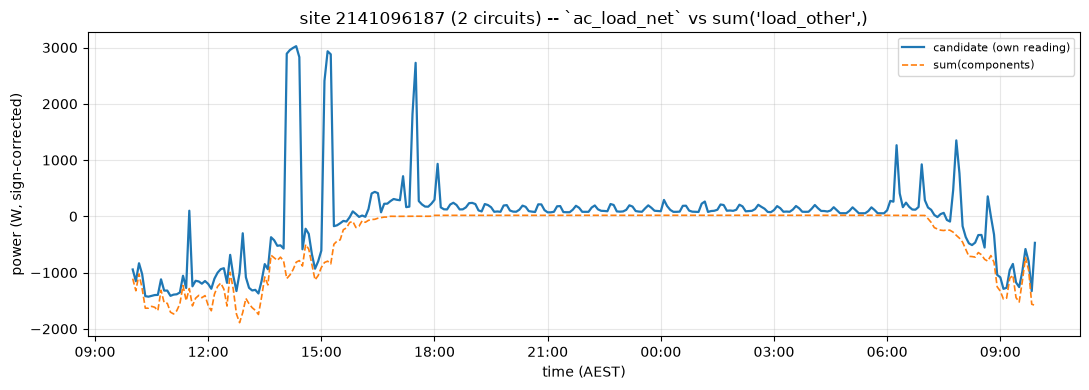

In [9]:
if aggregation_checks:
    results_table = pd.DataFrame([vars(c) for c in aggregation_checks])
    results_table["n_circuits_tested"] = results_table.component_types.apply(len) + 1
    display(results_table)

    # dropna=False: value_counts() silently drops None (inconclusive) verdicts
    # by default, which would hide them from this summary entirely.
    summary = results_table.groupby("candidate_type").is_aggregate.value_counts(dropna=False)
    print("\nVerdict counts by candidate_type:")
    print(summary)

    # Plot the SIMPLEST tested site (fewest circuits) -- easiest to read, not
    # necessarily the first one the loop happened to run. Restricted to
    # CONCLUSIVE verdicts only: an inconclusive check (too few overlapping
    # intervals) has no sum(components) line to draw, so picking on
    # n_circuits_tested alone can silently choose a site with nothing to plot.
    conclusive = results_table[results_table.is_aggregate.notna()]
    if len(conclusive):
        simplest = conclusive.sort_values("n_circuits_tested").iloc[0]
    else:
        simplest = results_table.sort_values("n_circuits_tested").iloc[0]
        print()
        print("WARNING: no conclusive aggregation check among the tested sites -- falling "
              "back to the simplest INCONCLUSIVE one; the plot below will show only one line.")
    simplest_sample = aggregation_samples[simplest.site_id]
    simplest_candidate_ids = simplest_sample[
        simplest_sample.circuit_type == simplest.candidate_type
    ].circuit_id.unique().tolist()
    simplest_component_ids = simplest_sample[
        simplest_sample.circuit_type.isin(simplest.component_types)
    ].circuit_id.unique().tolist()
    # Actual circuit-id count, not len(component_types)+1 -- a circuit_type
    # can map to more than one circuit_id at a site (seen in real data: three
    # separate circuit_ids all tagged `ac_load_net` at one site), which the
    # type-count undercounts.
    simplest_n_circuits = len(simplest_candidate_ids) + len(simplest_component_ids)
    fig, ax = Plots.plot_aggregation_check(
        simplest_sample, candidate_circuit_ids=simplest_candidate_ids,
        component_circuit_ids=simplest_component_ids,
        title=f"site {simplest.site_id} ({simplest_n_circuits} circuits) -- "
              f"`{simplest.candidate_type}` vs sum{simplest.component_types}",
    )
    plt.show()
else:
    print("No aggregation checks ran -- nothing to display.")


## 5. Circuit-polarity sign-convention verification

Reuses the real samples already pulled in section 4 -- no new query. Checks,
per circuit_type, whether `power * circuit_polarity` is consistently one
sign (confirming the fixed-sign assumption Stage 1 makes for PV) or
genuinely bidirectional (a real signal for `ami_config.STORAGE_HANDLING`, or
for an unexpectedly bidirectional "load", not just a name match).


In [10]:
if aggregation_samples:
    combined_sample = pd.concat(aggregation_samples.values(), ignore_index=True)
    polarity_check = Signal.verify_polarity_makes_positive(combined_sample)
    display(polarity_check)

    # share_negative/share_positive only count a reading past the noise floor
    # (default 50W) -- share_negative_raw/share_positive_raw (also in the
    # table above) keep the old sign-only count, so a fleet run doesn't get
    # silently reclassified without visibility into how much the floor
    # actually changed the verdict for each circuit_type.
    floor_changed = polarity_check[
        (polarity_check.share_negative_raw - polarity_check.share_negative).abs() > 0.01
    ]
    if len(floor_changed):
        print(f"\n{len(floor_changed)} circuit_type(s) had their negative-share reading "
              "change by more than 1 percentage point once the noise floor was applied "
              "-- see share_negative_raw vs share_negative above:")
        print(floor_changed[["circuit_type", "share_negative_raw", "share_negative"]]
              .to_string(index=False))

    bidirectional_types = polarity_check[polarity_check.bidirectional].circuit_type.tolist()
    if bidirectional_types:
        print(f"\nBIDIRECTIONAL circuit_type(s) found: {bidirectional_types} -- "
              "confirmed by data, not just by name. If any of these is your dominant "
              "gross_load/pv_generation candidate, this needs resolving before Phase 4: "
              "a meter that is negative a third of the time is not behaving as a pure "
              "consumption/generation signal.")
    else:
        print("\nNo circuit_type in this sample showed real bidirectional behaviour "
              "(share on both sides of zero above the threshold).")
else:
    combined_sample = pd.DataFrame()
    print("No real samples available (RUN_AGGREGATION_CHECKS was False) -- skipped.")


,circuit_type,n,share_negative_raw,share_positive_raw,share_negative,share_positive,bidirectional
0,ac_load_net,2016,0.245040,0.754960,0.232143,0.720238,True
1,load_air_conditioner,288,0.000000,1.000000,0.000000,0.086806,False
2,load_other,1152,0.201389,0.548611,0.179688,0.250000,True
3,load_powerpoint,576,0.500000,0.500000,0.173611,0.039931,False



3 circuit_type(s) had their negative-share reading change by more than 1 percentage point once the noise floor was applied -- see share_negative_raw vs share_negative above:
   circuit_type  share_negative_raw  share_negative
    ac_load_net            0.245040        0.232143
     load_other            0.201389        0.179688
load_powerpoint            0.500000        0.173611

BIDIRECTIONAL circuit_type(s) found: ['ac_load_net', 'load_other'] -- confirmed by data, not just by name. If any of these is your dominant gross_load/pv_generation candidate, this needs resolving before Phase 4: a meter that is negative a third of the time is not behaving as a pure consumption/generation signal.


## 6. `energy` confirmed to match `power` * interval -- no unit guessing needed

Earlier versions of this notebook only ever queried `power`, `energy_reactive`,
and `voltage` from `ts` -- a narrower column list inherited from the Stage 1
pipeline, not a fact about the source table. Without a real `energy` column to
calibrate against, `energy_reactive`'s units had to be GUESSED between two
hypotheses via an indirect plausibility check (see
`ami_resample.verify_column_units`, kept for the historical record).

The real `ts` schema removes the need to guess: it already provides
`energy`, `energy_import`, `energy_export`, `energy_reactive_import`, and
`energy_reactive_export` directly, alongside `power_factor` and `current`.
Sections 4/8/9's queries now pull all of them. This cell just CONFIRMS the
relationship `energy`'s name promises (`energy` = `power` * interval_hours),
the same spot-check any other named column deserves before being trusted --
not a hypothesis test, because there is nothing left to choose between.


In [11]:
if len(combined_sample):
    energy_check = Resample.confirm_energy_matches_power(
        combined_sample, interval_minutes=Config.SOURCE_INTERVAL_MINUTES,
    )
    for key, value in energy_check.items():
        print(f"{key}: {value}")

    if energy_check["confirmed"]:
        print("\nCONFIRMED -- `energy`/`energy_import`/`energy_export`/"
              "`energy_reactive`/`energy_reactive_import`/`energy_reactive_export` "
              "can all be used directly as-is: no renaming, no unit conversion, no "
              "multiplier. The only real mapping Phase 4 needs is circuit_type -> "
              "role (`Signal.build_signal_map`), not source-column reinterpretation.")
    else:
        print("\nWARNING -- `energy` does not reliably match `power` * interval here "
              "-- see the follow-up check below before trusting it blindly in Phase 4.")
else:
    energy_check = {"confirmed": None, "reason": "no sample available"}
    print("No real sample available -- skipped.")


n_rows: 4032
n_mismatched: 752
share_mismatched: 0.1865079365079365
confirmed: False
reason: 752 of 4,032 row(s) (18.65%) differ from `power` * interval_hours by more than 0.5 Wh -- exceeds the allowed mismatch share, do not trust `energy` blindly here

WARNING -- `energy` does not reliably match `power` * interval here -- see the follow-up check below before trusting it blindly in Phase 4.


In [12]:
combined_sample.to_csv("comparison_frame.csv", index=False)

### 6b. If `energy` didn't match: missed-poll gap, or something else?

Only runs if the check above came back `confirmed=False`. Real AMI feeds
miss polls: a circuit's next `ts` row can arrive later than the nominal
interval after a dropped report -- the same real-world fleet churn
`sites_missing_day_data` already accounts for at the whole-day level, just
showing up here at the individual-reading level instead. If `energy` is a
genuinely-measured register delta for the ACTUAL elapsed time, comparing it
against `power` times a fixed NOMINAL interval will mismatch on exactly
those rows even though `energy` is correct -- a false alarm above, not a
real units problem. This recomputes the expected value from each row's own
measured gap to test that directly, and breaks the (nominal-interval)
mismatch down by `circuit_type` in case it concentrates somewhere specific
instead (e.g. one appliance type, or PV specifically).


In [13]:
if not energy_check.get("confirmed") and len(combined_sample):
    actual_check = Resample.confirm_energy_matches_power_actual_interval(
        combined_sample, group_column="circuit_type",
    )
    for key, value in actual_check.items():
        print(f"{key}: {value}")

    if actual_check["confirmed"]:
        print(f"\nCONFIRMED once each row's ACTUAL interval is used instead of the "
              f"nominal {Config.SOURCE_INTERVAL_MINUTES}-minute assumption -- the "
              "earlier mismatch was missed-poll gaps, not a units problem. `energy` "
              "is still directly usable, but Phase 4 code that assumes a UNIFORM "
              "interval per row should derive it from consecutive `t_stamp` values "
              "per circuit, not assume a constant interval everywhere.")
    else:
        print("\nSTILL not confirmed against each row's own actual interval -- this "
              "is not (only) a missed-poll artifact. Check the by-circuit_type "
              "breakdown below (and above, for the nominal-interval version) for "
              "where it concentrates before trusting `energy` in Phase 4.")

    nominal_breakdown = Resample.confirm_energy_matches_power(
        combined_sample, interval_minutes=Config.SOURCE_INTERVAL_MINUTES,
        group_column="circuit_type",
    ).get("share_mismatched_by_group")
    if nominal_breakdown:
        print("\nNominal-interval mismatch share by circuit_type:")
        display(pd.Series(nominal_breakdown, name="share_mismatched").to_frame())

    actual_breakdown = actual_check.get("share_mismatched_by_group")
    if actual_breakdown:
        print("\nActual-interval mismatch share by circuit_type:")
        display(pd.Series(actual_breakdown, name="share_mismatched").to_frame())

    # Cross-reference against section 5's bidirectional finding: a circuit
    # that reverses direction WITHIN one interval has BOTH `energy_import`
    # and `energy_export` nonzero for that same row -- the register nets
    # them correctly (`energy = energy_import - energy_export`), but a
    # single `power` reading (however it is sampled/averaged over the
    # interval) can diverge from that correctly-netted value whenever a
    # real reversal happens inside the window. A steady, one-directional
    # load never has both nonzero in the same interval, so it never has
    # this problem -- which is exactly why section 5's bidirectional
    # circuit_types and this mismatch should be the same ones, not a
    # coincidence.
    mismatched_types = {t for t, share in (nominal_breakdown or {}).items() if share > 0.01}
    bidirectional_types = set(polarity_check[polarity_check.bidirectional].circuit_type)
    overlap = mismatched_types & bidirectional_types
    if overlap:
        print(f"\nCross-reference with section 5: {sorted(overlap)} were ALSO flagged "
              "bidirectional there (real negative AND positive shares, not noise) -- "
              "consistent with the mechanism above, not a coincidence.")
    elif mismatched_types:
        print(f"\nCross-reference with section 5: {sorted(mismatched_types)} mismatch here "
              "but were NOT flagged bidirectional there -- the mechanism above may not be "
              "the (whole) explanation for these; worth a closer look before trusting `energy`.")

    # Test the mechanism directly, row by row, rather than relying only on
    # the circuit_type-level correlation above.
    combined_sample["_bidirectional_interval"] = (
        (combined_sample.energy_import > 0) & (combined_sample.energy_export > 0)
    )
    bidirectional_interval_check = Resample.confirm_energy_matches_power(
        combined_sample, interval_minutes=Config.SOURCE_INTERVAL_MINUTES,
        group_column="_bidirectional_interval",
    ).get("share_mismatched_by_group")
    if bidirectional_interval_check:
        print("\nMismatch share by 'did this row see BOTH import and export "
              "(energy_import>0 AND energy_export>0)':")
        display(pd.Series(bidirectional_interval_check, name="share_mismatched").to_frame())
        print("If the 'True' row is far higher than 'False', the mismatch concentrates in "
              "intervals that genuinely reversed direction -- `energy` is still correct, it "
              "is `power` (one reading for an interval that was not one-directional) that "
              "cannot represent both a net-positive and net-negative interval at once.")
else:
    print("Section 6 already confirmed (or no sample) -- no follow-up needed.")


n_rows: 4018
n_mismatched: 747
share_mismatched: 0.18591338974614235
confirmed: False
reason: 747 of 4,018 row(s) (18.59%) differ from `power` * ACTUAL-interval-hours (from consecutive `t_stamp` gaps on the same circuit, not the nominal interval) by more than 0.5 Wh
share_mismatched_by_group: {'ac_load_net': 0.23992035838725734, 'load_other': 0.2308362369337979, 'load_air_conditioner': 0.0, 'load_powerpoint': 0.0}

STILL not confirmed against each row's own actual interval -- this is not (only) a missed-poll artifact. Check the by-circuit_type breakdown below (and above, for the nominal-interval version) for where it concentrates before trusting `energy` in Phase 4.

Nominal-interval mismatch share by circuit_type:


,share_mismatched
ac_load_net,0.240575
load_other,0.231771
load_air_conditioner,0.000000
load_powerpoint,0.000000



Actual-interval mismatch share by circuit_type:


,share_mismatched
ac_load_net,0.239920
load_other,0.230836
load_air_conditioner,0.000000
load_powerpoint,0.000000



Cross-reference with section 5: ['ac_load_net', 'load_other'] were ALSO flagged bidirectional there (real negative AND positive shares, not noise) -- consistent with the mechanism above, not a coincidence.

Mismatch share by 'did this row see BOTH import and export (energy_import>0 AND energy_export>0)':


,share_mismatched
True,0.246154
False,0.184521


If the 'True' row is far higher than 'False', the mismatch concentrates in intervals that genuinely reversed direction -- `energy` is still correct, it is `power` (one reading for an interval that was not one-directional) that cannot represent both a net-positive and net-negative interval at once.


### 6c. Something else: a device/meter-model effect?

Section 6b's cross-reference above is a circuit_type-LEVEL correlation
(`ac_load_net`/`load_other` are the only bidirectional types, and the only
ones that mismatch) -- but the row-level `_bidirectional_interval` test
right above it tests the same-row mechanism directly, and on a real sample
mostly does NOT bear it out: most mismatched rows do not have both
`energy_import>0` and `energy_export>0` in the same row. So bidirectionality
correlates with WHICH circuit_types mismatch, but does not explain most of
the actual mismatched ROWS within them -- something else is also going on.

This checks a different, device-level hypothesis instead: does `energy`
behave as a genuinely continuous value (matches `power * interval` to
ordinary floating-point tolerance), or does it look like a whole-watt-hour
REGISTER read on an internal accumulation window that isn't quite the
nominal interval? A circuit whose `t_stamp` gaps land exactly on the
nominal grid can still have this problem -- its LOGGING cadence isn't
drifting, only its internal accumulation window is a little short or long,
which section 6b's actual-interval check (built from `t_stamp` gaps) cannot
see. Cross-referenced against `device_type` (now in `meta_local`, thanks to
section 3c) in case this splits along the two documented hardware brands
(`CATCH Power`, `Watt Watcher`).

In [14]:
if not energy_check.get("confirmed") and len(combined_sample):
    granularity = Resample.energy_granularity_and_implied_interval(combined_sample)
    granularity = granularity.merge(
        combined_sample[["circuit_id", "circuit_type"]].drop_duplicates("circuit_id"),
        on="circuit_id", how="left",
    )
    if "device_type" in meta_local.columns:
        granularity = granularity.merge(
            meta_local[["circuit_id", "device_type"]].drop_duplicates("circuit_id"),
            on="circuit_id", how="left",
        )
    display(granularity)

    NOMINAL_MINUTES = Config.SOURCE_INTERVAL_MINUTES
    flagged = granularity[
        (granularity.share_integer_energy > 0.9)
        & ((granularity.implied_interval_minutes - NOMINAL_MINUTES).abs() / NOMINAL_MINUTES > 0.01)
    ]
    if len(flagged):
        print(f"\n{len(flagged)} of {len(granularity)} circuit_id(s) show a whole-Wh "
              f"`energy` register (share_integer_energy > 0.9) whose implied interval "
              f"differs from the nominal {NOMINAL_MINUTES}-minute assumption by more than "
              "1% -- this is the device/meter-model signature, distinct from bidirectionality:")
        display_columns = ["circuit_id", "circuit_type"]
        if "device_type" in flagged.columns:
            display_columns.append("device_type")
        display_columns += ["share_integer_energy", "implied_interval_minutes", "n_rows"]
        display(flagged[display_columns])

        # Direct answer to "is this the device brand": a per-device_type
        # breakdown, not just a disjoint-sets check -- makes the split (or
        # lack of one) visible as a table rather than a single yes/no line.
        if "device_type" in granularity.columns and granularity.device_type.notna().any():
            granularity["_flagged"] = granularity.circuit_id.isin(flagged.circuit_id)
            by_device_type = granularity.groupby("device_type").agg(
                n_circuits=("circuit_id", "nunique"),
                n_flagged=("_flagged", "sum"),
                mean_share_integer_energy=("share_integer_energy", "mean"),
                mean_implied_interval_minutes=("implied_interval_minutes", "mean"),
            ).reset_index()
            by_device_type["share_flagged"] = by_device_type.n_flagged / by_device_type.n_circuits
            by_device_type = by_device_type.sort_values("share_flagged", ascending=False)
            print("\nBreakdown by device_type -- this is the direct check for whether it's "
                  "the device brand:")
            display(by_device_type[[
                "device_type", "n_circuits", "n_flagged", "share_flagged",
                "mean_share_integer_energy", "mean_implied_interval_minutes",
            ]])

            if len(by_device_type) > 1 and by_device_type.share_flagged.max() > 0.5 \
                    and by_device_type.share_flagged.min() < 0.1:
                worst = by_device_type.iloc[0]
                print(f"\n`{worst.device_type}` shows the signature in "
                      f"{worst.share_flagged:.0%} of its circuits, well above every other "
                      "device_type -- consistent with a device_type-specific effect, not a "
                      "circuit_type one.")
            elif len(by_device_type) > 1:
                print("\nNo device_type cleanly separates flagged from clean circuits here "
                      "-- look for a finer attribute (specific `model`, firmware, or install "
                      "date) before concluding it is hardware-wide.")
            else:
                print(f"\nOnly one device_type (`{by_device_type.device_type.iloc[0]}`) "
                      "appears in this sample at all -- cannot test the device-brand "
                      "hypothesis until a sample spans more than one.")
        else:
            print("\n`device_type` not available in this sample (re-run after section 3c's "
                  "meta_local SELECT expansion) -- cannot check the device-brand hypothesis "
                  "yet.")

        print("\nIf this is confirmed as a real device/meter-model effect: for these "
              "specific circuit_id(s), neither `power` (section 6) nor the `t_stamp`-gap "
              "actual-interval correction (section 6b) can be trusted to derive power "
              "directly -- `energy / implied_interval_minutes` (this circuit's OWN implied "
              "interval, not the nominal or t_stamp-gap one) is the more defensible "
              "derivation for them specifically, pending confirmation against a longer "
              "sample and, ideally, the hardware vendor's own documented accumulation "
              "behaviour.")
    else:
        print("\nNo circuit_id shows this whole-Wh-register-with-short-interval signature "
              "-- the mismatch here is not (fully) explained by this mechanism either; see "
              "the by-circuit_id table above for anything else worth a closer look.")
else:
    print("Section 6 already confirmed (or no sample) -- no follow-up needed.")

,circuit_id,n_rows,share_integer_energy,implied_interval_minutes,n_rows_used_for_ratio,circuit_type,device_type
0,228861,288,0.000000,5.000001,8,load_powerpoint,Watt Watcher
1,228863,288,0.000000,5.000000,213,ac_load_net,Watt Watcher
2,289203,288,0.000000,5.000002,13,load_powerpoint,Watt Watcher
3,289206,288,0.000000,5.000000,219,ac_load_net,Watt Watcher
4,328450,288,0.000000,5.000000,258,ac_load_net,Watt Watcher
5,328452,288,0.000000,5.000000,25,load_air_conditioner,Watt Watcher
6,514177,288,0.003472,5.000000,126,load_other,Watt Watcher
7,514179,288,0.000000,5.000000,277,ac_load_net,Watt Watcher
8,635549,288,1.000000,4.889618,132,ac_load_net,CATCH Power
9,635550,288,1.000000,4.903011,102,load_other,CATCH Power



5 of 14 circuit_id(s) show a whole-Wh `energy` register (share_integer_energy > 0.9) whose implied interval differs from the nominal 5-minute assumption by more than 1% -- this is the device/meter-model signature, distinct from bidirectionality:


,circuit_id,circuit_type,device_type,share_integer_energy,implied_interval_minutes,n_rows
8,635549,ac_load_net,CATCH Power,1.0,4.889618,288
9,635550,load_other,CATCH Power,1.0,4.903011,288
10,656665,ac_load_net,CATCH Power,1.0,4.887718,288
11,656666,load_other,CATCH Power,1.0,4.904376,288
12,668971,ac_load_net,CATCH Power,1.0,4.919685,288



Breakdown by device_type -- this is the direct check for whether it's the device brand:


,device_type,n_circuits,n_flagged,share_flagged,mean_share_integer_energy,mean_implied_interval_minutes
0,CATCH Power,6,5,0.833333,1.000000,4.900882
1,Watt Watcher,8,0,0.0,0.000434,5.000000



`CATCH Power` shows the signature in 83% of its circuits, well above every other device_type -- consistent with a device_type-specific effect, not a circuit_type one.

If this is confirmed as a real device/meter-model effect: for these specific circuit_id(s), neither `power` (section 6) nor the `t_stamp`-gap actual-interval correction (section 6b) can be trusted to derive power directly -- `energy / implied_interval_minutes` (this circuit's OWN implied interval, not the nominal or t_stamp-gap one) is the more defensible derivation for them specifically, pending confirmation against a longer sample and, ideally, the hardware vendor's own documented accumulation behaviour.


## 7. Resample-rule demonstration

Pure -- no query. Takes one real circuit's 5-minute `power` readings from the
sample already pulled and resamples to a 30-minute bucket via
`Resample.resample_to_interval`, printing the raw values alongside the
bucketed result so the arithmetic can be eyeballed, not just trusted.


In [15]:
if len(combined_sample):
    demo_circuit_id = combined_sample.circuit_id.iloc[0]
    demo = combined_sample[combined_sample.circuit_id == demo_circuit_id].sort_values("t_stamp")
    first_half_hour = demo.head(6)[["t_stamp", "power"]]
    print(f"circuit {demo_circuit_id} -- first half hour, raw 5-min power (W):")
    display(first_half_hour)

    hand_check_kwh = sum(
        Resample.interval_energy_kwh(pd.Series([p]), source_interval_minutes=5).iloc[0]
        for p in first_half_hour.power
    )
    print(f"hand-summed energy for these 6 intervals: {hand_check_kwh:.4f} kWh")

    resampled = Resample.resample_to_interval(
        demo[["t_stamp", "power"]].assign(circuit_id=demo_circuit_id),
        time_column="t_stamp", group_columns=["circuit_id"],
        energy_like_columns={"power": False},
        source_interval_minutes=Config.SOURCE_INTERVAL_MINUTES,
        target_interval_minutes=30,
    )
    print("\n`resample_to_interval`'s first 30-min bucket:")
    display(resampled.head(1))
else:
    print("No real sample available -- skipped.")


circuit 635549 -- first half hour, raw 5-min power (W):


,t_stamp,power
0,2025-06-01 00:00:00,-944.48
1,2025-06-01 00:05:00,-1153.89
2,2025-06-01 00:10:00,-833.42
3,2025-06-01 00:15:00,-1027.48
4,2025-06-01 00:20:00,-1418.25
5,2025-06-01 00:25:00,-1427.96


hand-summed energy for these 6 intervals: -0.5671 kWh

`resample_to_interval`'s first 30-min bucket:


,circuit_id,t_stamp,power
0,635549,2025-06-01,-0.567123


## 8. Example daily curves -- unpack one site's circuits

Set `INSPECT_SITE_ID` below to any site_id you want to look at -- defaults
to the simplest CONCLUSIVE site from section 4, but this is not limited to
that site; change the id and re-run this cell to unpack a different one.
`example_sites_by_ac_load_net_count` (computed below, before the main
block) gives one example site_id for each `ac_load_net` count from 0 to 6
seen in the PV cohort (section 3b) -- set `INSPECT_SITE_ID =
example_sites_by_ac_load_net_count[3]`, for instance, to look at a
3-circuit (candidate 3-phase) site specifically.

Unlike section 4 (which only pulls the candidate type plus its declared
load-side siblings), this section pulls **every circuit_id present at the
site**, on both sides of the meter, by querying `meta_up23c` for the site's
full roster first -- circuit COUNT here means distinct `circuit_id`, not
distinct `circuit_type` (a real fleet pattern this caught: one site had
THREE separate circuit_ids all sharing the `ac_load_net` type, which a
type-based count would silently under-report as one).

It also runs `ami_taxonomy.find_duplicate_circuits` on whatever comes back:
a real finding this surfaced is two circuit_ids at one site -- one tagged a
load type, one tagged the PV type -- whose RAW readings were identical up to
a sign flip, i.e. the same physical circuit double-tagged, not two genuinely
separate signals. Summing that "load" into `gross_load` would double-count
the PV reading with a sign error. This check is cheap (reuses the data this
cell already pulled, no new query) and worth reading before trusting "sum of
all loads besides PV" at any site.

A site can also have several circuit_ids of the SAME type that are not
duplicates of a live signal but simply dead: `ami_taxonomy.find_inactive_circuits`
flags any circuit_id whose reading never clears a few Watts in this window --
the other real pattern behind "why does this site have 3 `ac_load_net`
circuit_ids", distinct from mirroring (one live signal reported twice).

**Window: 2 full AEST calendar days** (midnight to midnight AEST x2), not
the UTC day section 4 used -- built via `Plots.aest_day_window_utc` rather
than reusing `AGGREGATION_DAY_START`/`AGGREGATION_DAY_END` directly, since
those are UTC bounds and would show 10:00 AEST to 10:00 AEST, not midnight
to midnight (see that function's docstring). Change `N_INSPECT_DAYS` below
for a different window length.

**Expected scan volume:** up to 2 small queries (one per `is_pv` side
actually present at the site), each pruned to this one site's circuit_ids
over the 2-day window above -- still a few-MB-per-query pattern, just
roughly double the volume of a 1-day pull.

Example site_id for each `ac_load_net` count (0-6), where the fleet has one:
  0 circuit(s): site_id = 615248
  1 circuit(s): site_id = 130538
  2 circuit(s): site_id = 4116878
  3 circuit(s): site_id = 1002469
  4 circuit(s): site_id = 161468172
  5 circuit(s): site_id = 194103489
  6 circuit(s): site_id = 33683122

Set INSPECT_SITE_ID below to any of these (or any other site_id) and re-run this cell.

All circuits at site 2141096187 (from meta_up23c) -- 3 distinct circuit_id(s):


,circuit_id,circuit_type,is_pv,circuit_polarity
0,635549,ac_load_net,False,1
1,635550,load_other,False,1
2,635551,pv_site_net,True,-1



Inspecting 2 full AEST day(s): 2025-06-01 00:00:00+10:00 to 2025-06-03 00:00:00+10:00 AEST (UTC 2025-05-31 14:00:00 to 2025-06-02 14:00:00)

DUPLICATE/MIRRORED CIRCUITS DETECTED at this site -- these circuit_ids are reading the same physical signal, not independent circuits:


,site_id,circuit_id_a,circuit_id_b,correlation,sign,n_overlap
0,2141096187,635550,635551,1.0,same,576


Summing a flagged pair into `gross_load` double-counts one of them (with a sign error if `sign=opposite`) -- resolve which circuit_id is the real one before using either in the synthetic dataset.



,circuit_id,max_abs_power,inactive,circuit_type
0,635549,3076.00,False,ac_load_net
1,635550,1889.90,False,load_other
2,635551,1889.98,False,pv_site_net


No circuit at this site was inactive (all showed real activity in this window).



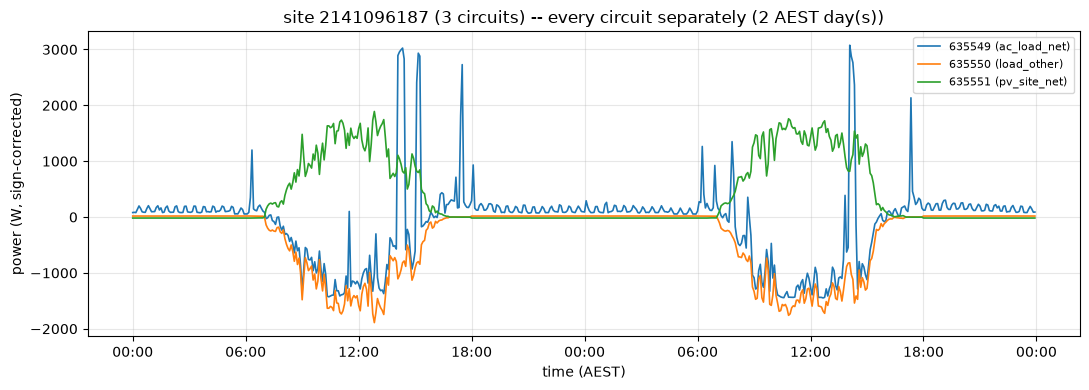

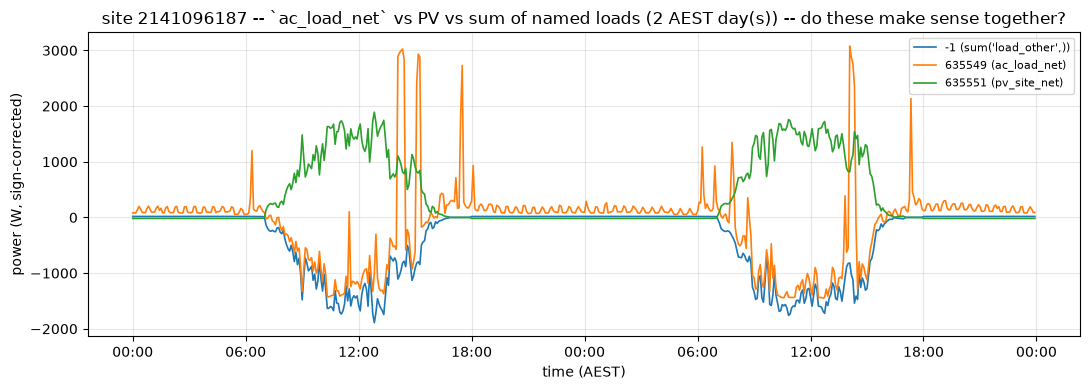

In [16]:
# One example site_id per `ac_load_net` count (0-6), from the PV cohort
# built in section 3b -- lets you jump straight to "a site with N circuits"
# instead of hunting for one by hand.
example_sites_by_ac_load_net_count = {}
if load_candidate_type and load_candidate_type in pv_cohort.columns:
    counts_for_examples = pv_cohort[["site_id", load_candidate_type]].rename(
        columns={load_candidate_type: "n_circuits"}
    )
    for n in range(0, 7):
        matches = counts_for_examples.loc[counts_for_examples.n_circuits == n, "site_id"]
        if len(matches):
            example_sites_by_ac_load_net_count[n] = int(matches.iloc[0])

    print(f"Example site_id for each `{load_candidate_type}` count (0-6), where the "
          "fleet has one:")
    for n in range(0, 7):
        site = example_sites_by_ac_load_net_count.get(n)
        print(f"  {n} circuit(s): site_id = {site}" if site is not None
              else f"  {n} circuit(s): no site found in this cohort")
    print("\nSet INSPECT_SITE_ID below to any of these (or any other site_id) and re-run "
          "this cell.\n")

if aggregation_checks:
    INSPECT_SITE_ID = simplest.site_id  # <-- change this, e.g. to
                                         #     example_sites_by_ac_load_net_count[3]

    site_all_meta = meta_local[meta_local.site_id == INSPECT_SITE_ID]
    n_site_circuits = site_all_meta.circuit_id.nunique()
    print(f"All circuits at site {INSPECT_SITE_ID} (from meta_up23c) -- "
          f"{n_site_circuits} distinct circuit_id(s):")
    display(site_all_meta[["circuit_id", "circuit_type", "is_pv", "circuit_polarity"]]
            .reset_index(drop=True))
    print()

    # Two full AEST calendar days (midnight to midnight AEST x2), not the
    # UTC day section 4 used -- see `Plots.aest_day_window_utc`'s docstring.
    INSPECT_AEST_DAY_START = AGGREGATION_DAY_START.split(" ")[0]
    N_INSPECT_DAYS = 2
    inspect_window = Plots.aest_day_window_utc(INSPECT_AEST_DAY_START, n_days=N_INSPECT_DAYS)
    print(f"Inspecting {N_INSPECT_DAYS} full AEST day(s): {inspect_window['aest_start']} to "
          f"{inspect_window['aest_end']} AEST "
          f"(UTC {inspect_window['start_utc']} to {inspect_window['end_utc']})")
    print()

    # Pull EVERY circuit_id at this site, whichever side of the meter it is
    # on -- `is_pv` is a partition column, so one query per side actually
    # present, not one query per named role the way section 4 does it.
    site_pulls = []
    for is_pv_value in (False, True):
        side_ids = site_all_meta[site_all_meta.is_pv == is_pv_value].circuit_id.tolist()
        if not side_ids:
            continue
        id_list_sql = ", ".join(str(int(c)) for c in side_ids)
        is_pv_sql = "true" if is_pv_value else "false"
        pulled = Athena.aq(
            f"""
            SELECT circuit_id, t_stamp, power, energy, energy_reactive, energy_import, energy_export, energy_reactive_import, energy_reactive_export, power_factor, voltage, current
            FROM ts
            WHERE ({inspect_window['year_month_sql']}) AND is_pv = {is_pv_sql}
              AND circuit_id IN ({id_list_sql})
              AND t_stamp >= TIMESTAMP '{inspect_window['start_utc']}'
              AND t_stamp <  TIMESTAMP '{inspect_window['end_utc']}'
            ORDER BY circuit_id, t_stamp
            """,
            database=Config.SAI,
            label=f"site inspection, site {INSPECT_SITE_ID}, is_pv={is_pv_value}",
        )
        site_pulls.append(pulled)

    site_sample = pd.concat(site_pulls, ignore_index=True) if site_pulls else pd.DataFrame()
    if len(site_sample):
        site_sample = site_sample.merge(
            site_all_meta[["circuit_id", "circuit_type", "circuit_polarity"]],
            on="circuit_id", how="left",
        )
        site_sample["power_signed"] = site_sample.power * site_sample.circuit_polarity

    # Duplicate/mirrored-circuit check -- pure post-processing on the sample
    # just pulled, no extra query. See `find_duplicate_circuits`'s docstring
    # for why this compares raw `power`, not the polarity-corrected column.
    if len(site_sample):
        dupes = Taxonomy.find_duplicate_circuits(
            site_sample.assign(site_id=INSPECT_SITE_ID)
        )
        if len(dupes):
            print("DUPLICATE/MIRRORED CIRCUITS DETECTED at this site -- these circuit_ids "
                  "are reading the same physical signal, not independent circuits:")
            display(dupes)
            print("Summing a flagged pair into `gross_load` double-counts one of them "
                  "(with a sign error if `sign=opposite`) -- resolve which circuit_id is "
                  "the real one before using either in the synthetic dataset.")
            print()
        else:
            print("No duplicate/mirrored circuits detected among this site's circuits.")
            print()

    # Inactive-circuit check -- the companion to the duplicate check above,
    # for the OTHER real pattern seen in the fleet: extra circuit_ids of one
    # circuit_type that are not duplicates of a live signal, but simply dead
    # (near-enough-constant zero) -- e.g. a site with 3 separate
    # `ac_load_net` circuit_ids where 2 are leftovers from a meter
    # re-registration, not a second/third genuine measurement to reconcile.
    if len(site_sample):
        inactive = Taxonomy.find_inactive_circuits(site_sample)
        inactive = inactive.merge(
            site_all_meta[["circuit_id", "circuit_type"]], on="circuit_id", how="left"
        )
        display(inactive)
        dead_ids = inactive[inactive.inactive].circuit_id.tolist()
        if dead_ids:
            print(f"INACTIVE circuit_id(s) at this site (max |power| under the threshold, "
                  f"i.e. effectively dead across this window): {dead_ids} -- likely a "
                  "retired/placeholder circuit_id left in meta_up23c after a meter or "
                  "logger was re-registered, not a genuine second measurement point.")
        else:
            print("No circuit at this site was inactive (all showed real activity in "
                  "this window).")
        print()

    # Plot 1: every circuit at this site separately, whatever its role --
    # the full picture, not just the candidate/siblings/PV roles section 4
    # happened to test.
    fig, ax = Plots.plot_circuit_day(
        site_sample,
        title=f"site {INSPECT_SITE_ID} "
              f"({site_sample.circuit_id.nunique() if len(site_sample) else 0} circuits) -- "
              f"every circuit separately ({N_INSPECT_DAYS} AEST day(s))",
    )
    plt.show()

    # Plot 2: candidate vs PV vs sum(named siblings) -- only meaningful for a
    # site section 4 actually tested (so the candidate/sibling ROLES are
    # known, not guessed here).
    site_check = next((c for c in aggregation_checks if c.site_id == INSPECT_SITE_ID), None)
    if site_check is not None and len(site_sample):
        pv_types_here = site_all_meta[site_all_meta.is_pv.astype(bool)].circuit_type.unique().tolist()
        siblings_only = site_sample[site_sample.circuit_type.isin(site_check.component_types)]
        gross_load_ex_pv = (
            siblings_only.groupby("t_stamp", as_index=False)["power_signed"].sum()
        )
        gross_load_ex_pv["circuit_id"] = -1
        gross_load_ex_pv["circuit_type"] = f"sum{site_check.component_types}"

        candidate_only = site_sample[site_sample.circuit_type == site_check.candidate_type]
        pv_only = site_sample[site_sample.circuit_type.isin(pv_types_here)]
        comparison_frame = pd.concat(
            [candidate_only, pv_only, gross_load_ex_pv], ignore_index=True
        )
        fig, ax = Plots.plot_circuit_day(
            comparison_frame,
            title=f"site {INSPECT_SITE_ID} -- `{site_check.candidate_type}` vs PV vs sum of "
                  f"named loads ({N_INSPECT_DAYS} AEST day(s)) -- do these make sense together?",
        )
        plt.show()
    else:
        print(f"Site {INSPECT_SITE_ID} was not one of section 4's tested sites (no known "
              "candidate/sibling roles to compare) -- showing the all-circuits plot only.")
else:
    print("No real samples available -- skipped.")

## 9. Does `pv_site_net` mean pure generation, or net-of-load?

Section 1 found `pv_site_net` dominates the PV side (99.6% of PV-side
circuits) and matches the "suspected aggregate" name pattern, so section 4
could not test it against real PV-side siblings -- fleet-wide there are
essentially none outside the single `pv_inverter` site. That leaves it
UNTESTED, not proven either way, and its shape in earlier runs (deeply
negative overnight, ramping toward positive during the day) is exactly what
you'd see from either hypothesis, so eyeballing one plot cannot settle it.

This section runs a check that does not need siblings: real PV generation is
~0 W in the dead of night, at every site, because there is no sunlight to
produce it -- a signal that is instead LARGE and negative overnight,
comparable to a household's normal night-time consumption, is not pure
generation; it is net of load. Where the same site also has a real load
candidate sample, the check additionally asks whether that load's own
night-time reading corroborates the size of the PV deficit -- corroborating
evidence only, not independent proof (see
`ami_signal.compare_pv_night_to_load`'s docstring for why).

**Expected scan volume:** up to `N_PV_DIAGNOSTIC_SITES` x 2 queries (the PV
candidate circuit, and the co-located load candidate circuit, at the same
site), each pruned to one site's circuit_ids over the SAME day as section 4,
with the `year`/`month`/`is_pv` partition predicate -- the same few-MB-per-
query pattern as section 4. Set `RUN_PV_NIGHT_DIAGNOSTIC = False` below to
skip all live queries in this section.


  site 130538: PV verdict=generation-like -- night mean -0.8 W is within +/-100 W of zero -- consistent with near-zero PV output overnight (at most inverter standby draw)
  site 1002469: PV verdict=None -- no sample, or missing time column
  site 1024617: PV verdict=generation-like -- night mean -1.0 W is within +/-100 W of zero -- consistent with near-zero PV output overnight (at most inverter standby draw)


,site_id,pv_candidate_type,load_candidate_type,pv_night_mean,pv_verdict,pv_reason,load_night_mean,corroborated,corroboration_reason
0,130538,pv_site_net,ac_load_net,-0.828697,generation-like,night mean -0.8 W is within +/-100 W of zero -...,1997.766478,None,PV verdict is not net-like -- no net-of-load h...
1,1002469,pv_site_net,ac_load_net,NaN,NaN,"no sample, or missing time column",NaN,None,PV verdict is not net-like -- no net-of-load h...
2,1024617,pv_site_net,ac_load_net,-0.988119,generation-like,night mean -1.0 W is within +/-100 W of zero -...,-366.392933,None,PV verdict is not net-like -- no net-of-load h...



0 of 3 tested site(s) show `pv_site_net` behaving NET-LIKE at night; 2 show GENERATION-LIKE behaviour. A verdict that varies by site is itself a finding, the same way section 4's aggregation verdicts are read.


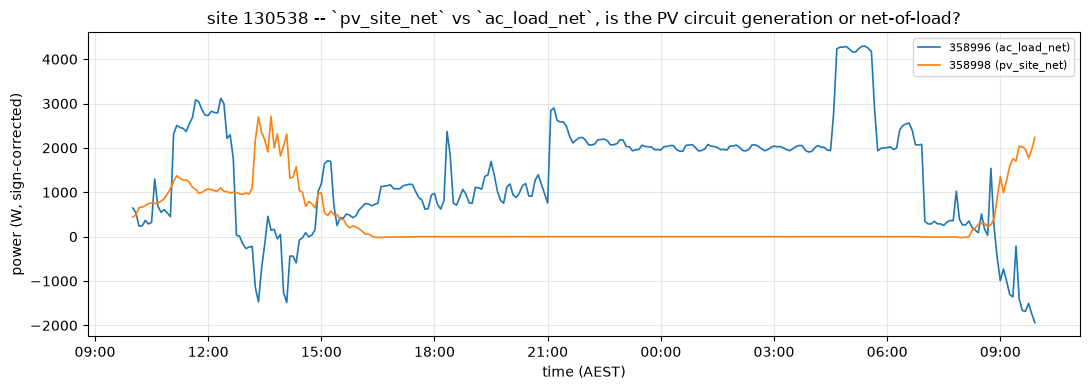

In [17]:
RUN_PV_NIGHT_DIAGNOSTIC = True  # set False to skip -- see the cost note above
N_PV_DIAGNOSTIC_SITES = 3
NIGHT_HOUR_START, NIGHT_HOUR_END = 1, 4  # AEST -- well inside guaranteed darkness fleet-wide

pv_night_results = []
pv_night_samples = {}  # site_id -> concatenated PV + load sample, for the example plot below

if RUN_PV_NIGHT_DIAGNOSTIC:
    pv_suspects = suspects[suspects.is_pv.astype(bool)].circuit_type.tolist()
    load_suspects = suspects[~suspects.is_pv.astype(bool)].circuit_type.tolist()

    if not pv_suspects:
        print("No PV-side circuit_type flagged as a suspected aggregate -- nothing to diagnose here.")
    else:
        pv_candidate_type = pv_suspects[0]
        load_candidate_type = load_suspects[0] if load_suspects else None

        diagnostic_sites = cohort_with_both[
            cohort_with_both[pv_candidate_type] > 0
        ].site_id.tolist()[:N_PV_DIAGNOSTIC_SITES] if pv_candidate_type in cohort_with_both.columns else []

        if not diagnostic_sites:
            print(f"No site in `cohort_with_both` has `{pv_candidate_type}` -- skipping.")

        def _pull_signed(site_meta, circuit_ids, is_pv_value, site_id):
            if not circuit_ids:
                return pd.DataFrame()
            id_list_sql = ", ".join(str(int(c)) for c in circuit_ids)
            is_pv_sql = "true" if is_pv_value else "false"
            raw = Athena.aq(
                f"""
                SELECT circuit_id, t_stamp, power, energy, energy_reactive, energy_import, energy_export, energy_reactive_import, energy_reactive_export, power_factor, voltage, current
                FROM ts
                WHERE year = {AGGREGATION_YEAR} AND month = {AGGREGATION_MONTH} AND is_pv = {is_pv_sql}
                  AND circuit_id IN ({id_list_sql})
                  AND t_stamp >= TIMESTAMP '{AGGREGATION_DAY_START}'
                  AND t_stamp <  TIMESTAMP '{AGGREGATION_DAY_END}'
                ORDER BY circuit_id, t_stamp
                """,
                database=Config.SAI,
                label=f"PV night diagnostic, site {site_id}, is_pv={is_pv_value}",
            )
            raw = raw.merge(
                site_meta[["circuit_id", "circuit_type", "circuit_polarity"]],
                on="circuit_id", how="left",
            )
            raw["power_signed"] = raw.power * raw.circuit_polarity
            raw["_t_aest"] = Plots.to_aest(raw.t_stamp)
            return raw

        for site_id in diagnostic_sites:
            site_meta = meta_local[meta_local.site_id == site_id]
            pv_ids = site_meta[site_meta.circuit_type == pv_candidate_type].circuit_id.tolist()
            load_ids = (
                site_meta[site_meta.circuit_type == load_candidate_type].circuit_id.tolist()
                if load_candidate_type else []
            )

            pv_sample = _pull_signed(site_meta, pv_ids, True, site_id)
            load_sample = _pull_signed(site_meta, load_ids, False, site_id)
            pv_night_samples[site_id] = pd.concat([pv_sample, load_sample], ignore_index=True)

            pv_stats = Signal.classify_pv_night_behaviour(
                pv_sample, time_column="_t_aest",
                night_hour_start=NIGHT_HOUR_START, night_hour_end=NIGHT_HOUR_END,
            )
            load_stats = Signal.night_window_stats(
                load_sample, time_column="_t_aest",
                night_hour_start=NIGHT_HOUR_START, night_hour_end=NIGHT_HOUR_END,
            )
            corroboration = Signal.compare_pv_night_to_load(pv_stats, load_stats)

            pv_night_results.append({
                "site_id": site_id,
                "pv_candidate_type": pv_candidate_type,
                "load_candidate_type": load_candidate_type,
                "pv_night_mean": pv_stats.get("night_mean"),
                "pv_verdict": pv_stats.get("verdict"),
                "pv_reason": pv_stats.get("reason"),
                "load_night_mean": load_stats.get("night_mean"),
                "corroborated": corroboration.get("corroborated"),
                "corroboration_reason": corroboration.get("reason"),
            })
            print(f"  site {site_id}: PV verdict={pv_stats.get('verdict')} -- {pv_stats.get('reason')}")

        if pv_night_results:
            pv_night_table = pd.DataFrame(pv_night_results)
            display(pv_night_table)

            n_net_like = (pv_night_table.pv_verdict == "net-like").sum()
            n_generation_like = (pv_night_table.pv_verdict == "generation-like").sum()
            print(f"\n{n_net_like} of {len(pv_night_table)} tested site(s) show `{pv_candidate_type}` "
                  f"behaving NET-LIKE at night; {n_generation_like} show GENERATION-LIKE behaviour. "
                  "A verdict that varies by site is itself a finding, the same way section 4's "
                  "aggregation verdicts are read.")

            net_like_rows = pv_night_table[pv_night_table.pv_verdict == "net-like"]
            example_site_id = (
                net_like_rows.iloc[0].site_id if len(net_like_rows) else pv_night_table.iloc[0].site_id
            )
            fig, ax = Plots.plot_circuit_day(
                pv_night_samples[example_site_id],
                title=f"site {example_site_id} -- `{pv_candidate_type}` vs `{load_candidate_type}`, "
                      "is the PV circuit generation or net-of-load?",
            )
            plt.show()
        else:
            pv_night_table = pd.DataFrame()
else:
    pv_night_table = pd.DataFrame()
    print("RUN_PV_NIGHT_DIAGNOSTIC is False -- skipped.")


In [18]:
display(Athena.scan_report())


18 queries, 5.67 GB scanned, ~AUD 0.0446 (billed at a 10.00 MB minimum per query)


,label,database,n_rows,seconds,scanned,scanned_bytes,cost,source
0,circuit_type census,solar_analytics_iceberg,33,3.01,1.14 MB,1.194973e+06,0.0001,query_metadata
1,meta_up23c full projection,solar_analytics_iceberg,60570,3.71,4.78 MB,5.007415e+06,0.0001,query_metadata
2,"day-coverage presence check, is_pv=False",solar_analytics_iceberg,14,2.94,153.18 MB,1.606221e+08,0.0012,query_metadata
3,"aggregation test sample, site 2141096187",solar_analytics_iceberg,576,4.00,512.54 MB,5.374423e+08,0.0039,query_metadata
4,"aggregation test sample, site 1387817",solar_analytics_iceberg,576,4.08,401.13 MB,4.206110e+08,0.0031,query_metadata
5,"aggregation test sample, site 2136269794",solar_analytics_iceberg,576,4.02,447.17 MB,4.688877e+08,0.0034,query_metadata
6,"aggregation test sample, site 2135732723",solar_analytics_iceberg,576,4.05,475.67 MB,4.987784e+08,0.0036,query_metadata
7,"aggregation test sample, site 864139763",solar_analytics_iceberg,576,2.88,370.52 MB,3.885223e+08,0.0028,query_metadata
8,"aggregation test sample, site 2121103676",solar_analytics_iceberg,576,4.10,440.58 MB,4.619860e+08,0.0034,query_metadata
9,"aggregation test sample, site 861912856",solar_analytics_iceberg,576,3.05,259.48 MB,2.720812e+08,0.0020,query_metadata


## 10. Summary -- pending your run

*(This section is written before you have run the notebook. I will revise it
to state actual findings, the same way notebooks 01 and 02's closing sections
were only finalised after you ran them -- placeholders below, not conclusions.)*

**What this notebook needs to tell us, and what I'll do with each once you've
run it and shared the output:**

- **Aggregation verdicts (section 4), across a spread of sites, not one.**
  A consistent verdict across all tested sites for a candidate_type resolves
  it (excluded into `ami_config.AGGREGATE_CIRCUIT_TYPES`, or kept as an
  ordinary signal). A verdict that varies by site is itself a finding worth
  discussing before Phase 4, not something to average away.
- **Storage (section 2 + 5).** Any circuit_type confirmed bidirectional
  becomes `ami_config.STORAGE_HANDLING`'s answer; none found means we record
  "no storage circuits identified in this fleet" rather than leaving the
  placeholder silently unresolved.
- **Column units (section 6).** Whichever hypothesis wins becomes
  `ami_config.SOURCE_COLUMN_UNITS_RESOLVED = True`, with the losing
  hypothesis's implausibility share recorded as the evidence. A thin margin
  (`margin_is_thin=True`) means re-testing on a bigger sample before trusting
  it, not accepting a coin-flip.
- **Fleet coverage (section 3).** `signal_coverage_summary`'s numbers go into
  `ami_config.py` as a Phase 3 finding, informing how much of the fleet Phase
  4/5 can actually build ground truth for.
- **PV signal semantics (section 9).** Whether `pv_site_net` (or whichever
  dominant PV candidate) behaves as pure generation or net-of-load determines
  how Phase 5 builds the `pv_generation` ground-truth signal -- a net-like
  verdict means this circuit cannot be used as generation ground truth as-is,
  and a separate net-of-load construction (or a different PV source column
  entirely) needs deciding before Phase 4.
- **Target interval.** Still your call, not something arithmetic decides --
  the 30-minute placeholder stands unless you say otherwise.

Once you've run this and shared what came back, I'll write the confirmed
values into `ami_config.py` (mirroring how Phase 1's and Phase 2's findings
were only written in after you'd seen and agreed with them), update
`ARCHITECTURE.md`'s phase-status row, and this section gets rewritten to
state the actual findings before we move to Phase 4.
